#### This notebook reproduces figure A5 in "Age-related vulnerability greatly amplifies the risk of uncompensable heat" by Kong et al.


In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import regionmask
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# directory to data; you might want to change it to your own directory
path='../data/'

#The number of young, middle-aged, and old people exposed in each individual country; for 15 climate models at 3°C warming
pop_exposed=xr.open_dataset(path+'Country_level_exposed_pop_num.nc').pop

# same as above but for total population of each age group
pop_total=xr.open_dataset(path+'Country_level_tot_pop_num.nc').pop

# get a list of countries and their abbreviations from regionmask
countries = np.array(regionmask.defined_regions.natural_earth.countries_50.names)
abb=np.array(regionmask.defined_regions.natural_earth.countries_50.abbrevs)

In [3]:
# fix abbreviation in regionmask: the abbreviations of some countries in regionmask are not two-letter.
abb[168]='AX'
abb[104]='EH'
abb[134]='JO'
abb[135]='JP'
abb[136]='JM'
abb[138]='IL'
abb[144]='IN'
abb[143]='ID'
abb[142]='IR'
abb[230]='AM'
abb[234]='AD'
abb[9]='FM'
abb[46]='SY'
abb[61]='SI'
abb[69]='SM'
abb[75]='RU'
abb[139]='PS'
abb[140]='IE'
abb[141]='IQ'
abb[169]='FI'
abb[172]='EE'
abb[191]='CD'
abb[212]='BA'
abb[5]='VA'
abb[48]='SE'
abb[54]='ES'
abb[78]='PT'
abb[88]='NO'
abb[112]='MT'
abb[119]='LU'
abb[137]='IT'
abb[156]='DE'
abb[160]='FR'
abb[217]='BE'
abb[224]='AT'

In [4]:
# select countries within regionmask that also appear in my data
mask=np.isin(countries,pop_exposed.country.values)
indices=np.where(mask)[0]
abb=abb[indices]
countries=countries[indices]

In [5]:
# caclulate the the number and percent of people exposed to at least 180 hours of uncompensable heat annually in each individual countries
# for both all people and specific age groups at 3°C warming
def calc_num_percent_exposed(age):
    if age=='all': # all age groups
        num=pop_exposed.sum('age') # exposed number 
        percent=pop_exposed.sum('age')/pop_total.sum('age') # exposed percentage
    else: # a specific age group
        num=pop_exposed.sel(age=age) # exposed number
        percent=pop_exposed.sel(age=age)/pop_total.sel(age=age) # exposed percentage
    # eliminates countries/regions where there is no population
    country_index_nonan=np.where(~np.isnan(percent[:,0]))[0]
    num=num[country_index_nonan,:]
    percent=percent[country_index_nonan,:]
    abr=abb[country_index_nonan]
    # calculate model ensemble mean
    num=num.mean('model')
    percent=percent.mean('model')
    # change population number to log scale
    num=xr.where(num==0,0,np.log10(num))
    # only retain countries with >0 people exposed
    percent=percent[np.where(num>0)]
    abr=abr[np.where(num>0)]
    num=num[np.where(num>0)]
    return (num,percent,abr)

num_all,percent_all,abr_all=calc_num_percent_exposed('all')


/home/kong97/.conda/envs/cent7/2020.02-py37/qin/lib/python3.9/site-packages/xarray/core/computation.py:742: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


In [6]:
# read in poverty rate dataset
def read_poverty(poverty_line):
    # poverty line threshold: 3.0, 4.2 or 8.3 dollar per day
    if poverty_line==3:
        file=path+'pip3.0.xlsx'
    elif poverty_line==4:
        file=path+'pip4.2.xlsx'
    elif poverty_line==8:
        file=path+'pip8.3.xlsx'
    df = pd.read_excel(file, engine='openpyxl')
    # only select years between 2016 and 2025
    df_filtered = df[(df['reporting_year'] >= 2016) & (df['reporting_year'] <= 2025)]
    # calculate the average poverty rate between 2016 and 2025
    mean_headcount = df_filtered.groupby(['country_name', 'country_code'])['headcount'].mean().reset_index()
    """
    some countries have different names in population exposure dataset and poverty dataset
    Here I adjust country names in poverty dataset to match the country names in population exposure dataset
    """
    mean_headcount['country_name'] = mean_headcount['country_name'].replace({
        'Viet Nam': 'Vietnam',
        'Yemen, Rep.': 'Yemen',
        'Micronesia, Fed. Sts.': 'Micronesia',
        'Marshall Islands': 'Marshall Is.',
        'United States':'United States of America',
        'South Sudan':'S. Sudan',
        'Korea, Rep.':'South Korea',
        'West Bank and Gaza':'Palestine',
        'Egypt, Arab Rep.':'Egypt',
        'Congo, Dem. Rep.':'Dem. Rep. Congo',
        'Congo, Rep.':'Congo',
        'Central African Republic':'Central African Rep.',
        "Cote d'Ivoire":"Côte d'Ivoire",
        'Syrian Arab Republic':'Syria',
        'Iran, Islamic Rep.':'Iran',
        'Gambia, The':'Gambia',
        'Lao PDR':'Laos',
        'Turkiye':'Turkey',
        'Solomon Islands':'Solomon Is.',
        'Sao Tome and Principe':'São Tomé and Principe',
        'Equatorial Guinea':'Eq. Guinea',
        'Dominican Republic':'Dominican Rep.',
    })
    """
    Some countries in population exposure dataset are not available in poverty dataset
    To solve this, I identify analog countries for them assuming they share similar poverty rates with their analogs
    """
    new_countries = {
        'Venezuela': 'Colombia',
        'N. Mariana Is.': 'Philippines',
        'U.S. Virgin Is.': 'United States of America',
        'Guam': 'Philippines',
        'American Samoa': 'Samoa',
        'Puerto Rico': 'United States of America',
        'Anguilla': 'Trinidad and Tobago',
        'Cayman Is.': 'Jamaica',
        'Bermuda': 'United Kingdom',
        'British Virgin Is.': 'Trinidad and Tobago',
        'Turks and Caicos Is.': 'Jamaica',
        'Montserrat': 'Jamaica',
        'Somalia': 'S. Sudan',
        'Singapore': 'Malaysia',
        'Saudi Arabia': 'United Arab Emirates',
        'St. Kitts and Nevis': 'Grenada',
        'Palau': 'Micronesia',
        'Oman': 'United Arab Emirates',
        'North Korea': 'Laos',
        'New Zealand': 'Australia',
        'Aruba': 'Trinidad and Tobago',
        'Curaçao': 'Trinidad and Tobago',
        'W. Sahara': 'Morocco',
        'Libya': 'Egypt',
        'Kuwait': 'Qatar',
        'Wallis and Futuna Is.': 'Fiji',
        'St-Martin': 'Dominican Rep.',
        'St-Barthélemy': 'Dominican Rep.',
        'Eritrea': 'Ethiopia',
        'Cuba': 'Dominican Rep.',
        'Cambodia': 'Laos',
        'Brunei': 'Malaysia',
        'Bahrain': 'Qatar',
        'Bahamas': 'Barbados',
        'Antigua and Barb.': 'Grenada',
        'Afghanistan': 'Yemen',
        'Sint Maarten': 'Dominican Rep.'
    }
    
    # Create a new list of rows to append
    new_rows = []
    for new_country, analog in new_countries.items():
        # Find analog value
        analog_row = mean_headcount[mean_headcount['country_name'] == analog]
        if not analog_row.empty:
            headcount_value = analog_row['headcount'].values[0]
            new_rows.append({
                'country_name': new_country,
                'country_code': 'XXX',
                'headcount': headcount_value
            })
        else:
            print(f"Analog country '{analog}' not found in the dataframe!")
    df_new = pd.DataFrame(new_rows)
    df_combined = pd.concat([mean_headcount, df_new])
    # create poverty ratio xarray of the same dimension and coords as the exposed population number and percent variable
    poverty_ratio=num_all*0-999
    for c in poverty_ratio['country'].values:
        poverty_ratio[poverty_ratio['country']==c]=df_combined[df_combined['country_name']==c]['headcount'].values.item()
    return poverty_ratio


In [7]:
poverty_ratio3=read_poverty(3) # $3 per day in 2021 Purchasing Power Parities
poverty_ratio4=read_poverty(4) # $4.2 per day in 2021 Purchasing Power Parities
poverty_ratio8=read_poverty(8) # $8.3 per day in 2021 Purchasing Power Parities

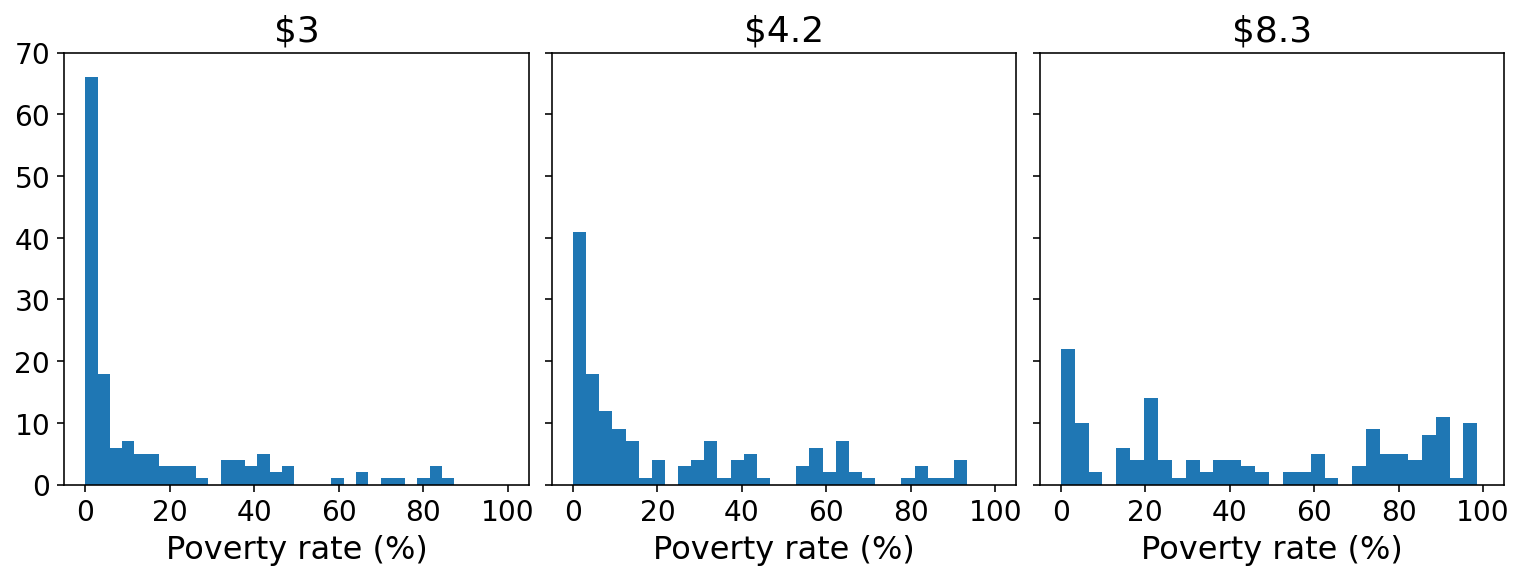

In [12]:
# plot poverty ratio distribution across countries
fig = plt.figure(figsize=(10,3))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.hist(poverty_ratio3,bins=30)
ax2.hist(poverty_ratio4,bins=30)
ax3.hist(poverty_ratio8,bins=30)

for axis in [ax1,ax2,ax3]:
    axis.tick_params(axis='both', labelsize=14)
    axis.set_xlabel('Poverty rate (%)',fontsize=16)
    axis.set_xlim([-0.05,1.05])
    axis.set_ylim([0,70])
    axis.set_xticks([0,0.2,0.4,0.6,0.8,1])
    axis.set_xticklabels(['0','20','40','60','80','100'])
    axis.set_yticks([0,10,20,30,40,50,60,70])

ax2.set_yticklabels([])
ax3.set_yticklabels([])

ax1.set_title('$3',fontsize=18)
ax2.set_title('$4.2',fontsize=18)
ax3.set_title('$8.3',fontsize=18)
fig.subplots_adjust(bottom=0, left=0,right=1, top=1,hspace=0,wspace=0.05)


**Figure A5**: Distribution of national poverty rates under three poverty lines: $\$$3 (left), $\$$4.2 (middle)
and $\$$8.3 (right) per day in 2021 Purchasing Power Parities